# Bootstrap Tutorial

This notebook introduces the opt-in bootstrap workflow in `pyjack`.

Key points:
- Bootstrap is activated with `method='bootstrap'`.
- Resampling is performed over the binned blocks, so `binsize` matters.
- The interval API supports `normal`, `percentile`, and `bca`.


In [1]:
import numpy
import pyjack
import matplotlib.pyplot as plt


## 1. Build a bootstrap observable

The bootstrap implementation resamples the binned primary configurations with replacement.

Practical reading of the options:
- `binsize` controls the block size used to reduce autocorrelation.
- `n_resamples` controls how many bootstrap replicas are generated.
- `seed` makes the bootstrap reproducible.

In [2]:
numpy.random.seed(42)

data = numpy.random.randn(100, 10) * 0.3 + 4.0

obs = pyjack.observable(description='Bootstrap tutorial observable')
obs.create(data, method='bootstrap', binsize=5, n_resamples=2000, seed=42)

print(obs)
print('resampling method =', obs.resampling_method)
print('replica array shape =', obs.jack_samples.shape)


pyjack(4.001(22), 4.000(25), 3.986(30), 4.032(23), 4.022(30), 3.991(33), 3.985(29), 4.010(27), 4.008(26), 4.018(28), description=Bootstrap tutorial observable)
resampling method = bootstrap
replica array shape = (2000, 10)


## 2. Propagate bootstrap errors through derived observables

Derived observables reuse the bootstrap replica axis, so arithmetic and common functions still work naturally.

In [3]:
squared = obs ** 2
exponential = pyjack.exp(obs)
summed = obs @ numpy.ones(data.shape[1])

print('squared:', squared)
print('exponential:', exponential)
print('summed:', summed)


squared: pyjack(16.01(18), 16.00(20), 15.89(24), 16.26(19), 16.18(24), 15.93(26), 15.88(23), 16.08(22), 16.07(21), 16.14(23), description=Bootstrap tutorial observable)
exponential: pyjack(54.6(12), 54.6(13), 53.9(16), 56.4(13), 55.9(16), 54.1(17), 53.8(15), 55.2(15), 55.1(14), 55.6(16), description=Bootstrap tutorial observable)
summed: pyjack(40.054(88), description=Bootstrap tutorial observable)


## 3. Confidence intervals

Three interval constructions are available:
- `normal`: symmetric interval from `mean +/- z * err`
- `percentile`: quantiles of the bootstrap replicas
- `bca`: bias-corrected and accelerated interval

Use `normal` when you want a simple Gaussian-style summary.
Use `percentile` when you want the interval to come directly from the bootstrap distribution.
Use `bca` when you want a more refined bootstrap interval that corrects for bias and skewness.

In [4]:
normal_ci = obs.confidence_interval(level=0.68, method='normal')
percentile_ci = obs.confidence_interval(level=0.68, method='percentile')
bca_ci = obs.confidence_interval(level=0.68, method='bca')

print('first component normal interval:', normal_ci[0][0], normal_ci[1][0])
print('first component percentile interval:', percentile_ci[0][0], percentile_ci[1][0])
print('first component bca interval:', bca_ci[0][0], bca_ci[1][0])


first component normal interval: 3.978208485092262 4.023145195898177
first component percentile interval: 3.977469711573401 4.022545269844747
first component bca interval: 3.9771616166773245 4.02214108475514


## 4. Slice observables and edit components

Slicing and assignment behave the same way as in the jackknife workflow. The bootstrap statistics are recomputed after assignment.

In [5]:
sliced = obs[2:5]
obs[2:5] = 2.0 * sliced
updated = obs[2:5]

print('original slice:', sliced)
print('updated slice:', updated)


original slice: pyjack(3.986(30), 4.032(23), 4.022(30), description=Bootstrap tutorial observable)
updated slice: pyjack(7.972(61), 8.064(47), 8.045(60), description=Bootstrap tutorial observable)


## 5. Fit directly from a bootstrap observable

The fitting stage uses the mean and covariance estimated from the bootstrap replicas.

[jackfit.fit] Fit did converge: [LevenbergMarquardt.minimize] Convergence with tolerance 1e-08 reached after 10 iterations. Exiting successfully
[jackfit.fit] chi2obs = 8.11648564446639
[jackfit.fit] chi2exp = 7.4231851053032685 +- 0.23474172425795184
[jackfit.fit] p-value = 0.3868 +- 0.004870415597750307
pyjack(4.008(21), 0.0037(36), description=Best parameters of fit)


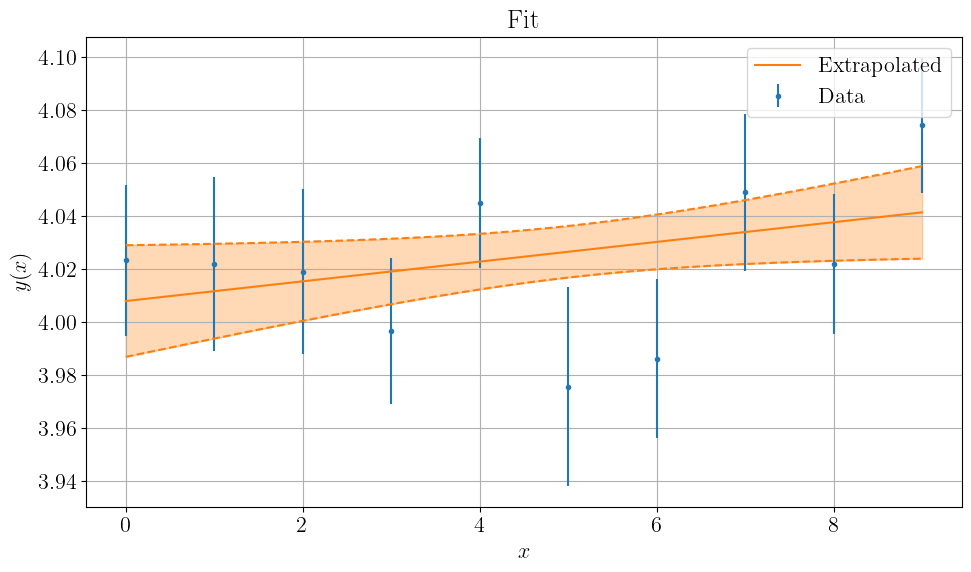

In [6]:
fit_data = numpy.random.randn(100, 10) * 0.3 + 4.0
fit_obs = pyjack.observable(description='Bootstrap fit data')
fit_obs.create(fit_data, method='bootstrap', binsize=5, n_resamples=2000, seed=123)

fitfunc = 'params0 + params1 * x'
initial_guess = [3.0, 0.0]
W = 'diag'

fit1 = pyjack.jackfit(fitfunc, W, initial_guess)
fit1.fit(numpy.arange(fit_obs.data.shape[1]), fit_obs, max_iter=1000, tol=1e-8, num_samples=10000)
print(fit1.params)
fit1.plot()


## 6. Increase statistics

Appending more configurations rebuilds the bootstrap analysis. The current implementation preserves the active resampling method and reuses the current number of replicas.

In [7]:
new_data = numpy.random.randn(1000, 10) * 0.3 + 4.0
fit_obs.increase_statistics(new_data)

fit2 = pyjack.jackfit(fitfunc, W, initial_guess)
fit2.fit(numpy.arange(fit_obs.data.shape[1]), fit_obs, max_iter=1000, tol=1e-8, num_samples=10000)
print(fit2.params)


[jackfit.fit] Fit did converge: [LevenbergMarquardt.minimize] Convergence with tolerance 1e-08 reached after 10 iterations. Exiting successfully
[jackfit.fit] chi2obs = 11.237102880882132
[jackfit.fit] chi2exp = 7.984035278347287 +- 0.25247736398713855
[jackfit.fit] p-value = 0.1863 +- 0.003893680402229678
pyjack(4.0060(56), -0.0017(10), description=Best parameters of fit)


## 7. Scalar observables from mean and covariance

An observable created from a mean and covariance can still participate in derived expressions. When combined with a bootstrap observable, `pyjack` generates synthetic replicas before propagating the operation.

In [8]:
mean = 2.0
cov = 0.003 ** 2

obs2 = pyjack.observable(description='Scalar observable')
obs2.create_from_cov(mean, cov)

print(obs * obs2)


pyjack(8.001(45), 8.000(50), 15.94(12), 16.128(95), 16.09(12), 7.982(66), 7.971(58), 8.021(55), 8.016(53), 8.036(57), description=Bootstrap tutorial observable)
